In [13]:
#pip install torch

In [29]:
def preprocess_fsc(df):
    # Combine action, object, location into a single intent string
    df['intent'] = df['action'].astype(str) + '_' + \
                   df['object'].astype(str) + '_' + \
                   df['location'].astype(str)
    return df

df_train = preprocess_fsc(pd.read_csv("data_fsc/train.csv"))
df_test = preprocess_fsc(pd.read_csv("data_fsc/test.csv"))

df_train.to_csv("data_fsc/train.csv", index=False)
df_test.to_csv("data_fsc/test.csv", index=False)

print(df_train.head())
print(df_train.columns)

   Unnamed: 0                                               path  \
0           0  wavs/speakers/2BqVo8kVB2Skwgyb/0a3129c0-4474-1...   
1           1  wavs/speakers/2BqVo8kVB2Skwgyb/0ee42a80-4474-1...   
2           2  wavs/speakers/2BqVo8kVB2Skwgyb/144d5be0-4474-1...   
3           3  wavs/speakers/2BqVo8kVB2Skwgyb/1811b6e0-4474-1...   
4           4  wavs/speakers/2BqVo8kVB2Skwgyb/1d9f3920-4474-1...   

          speakerId          transcription           action  object location  \
0  2BqVo8kVB2Skwgyb        Change language  change language    none     none   
1  2BqVo8kVB2Skwgyb                 Resume         activate   music     none   
2  2BqVo8kVB2Skwgyb     Turn the lights on         activate  lights     none   
3  2BqVo8kVB2Skwgyb   Switch on the lights         activate  lights     none   
4  2BqVo8kVB2Skwgyb  Switch off the lights       deactivate  lights     none   

                      intent  
0  change language_none_none  
1        activate_music_none  
2       activate_

In [31]:
import torch
import pandas as pd
import numpy as np
import random

def read_data(df_train_path, df_test_path):
    df_train = pd.read_csv(df_train_path, index_col=None)
    df_test = pd.read_csv(df_test_path, index_col=None)
    
    ## Prepare Labels
    labels = df_train['intent'].unique()
    label2id, id2label = dict(), dict()
    for i, label in enumerate(labels):
        label2id[label] = str(i)
        id2label[str(i)] = label
    num_labels = len(id2label)

    ## Train
    for index in range(0,len(df_train)):
        df_train.loc[index,'label'] = label2id[df_train.loc[index,'intent']]
    df_train['label'] = df_train['label'].astype(int)

    ## Validation
    for index in range(0,len(df_test)):
        df_test.loc[index,'label'] = label2id[df_test.loc[index,'intent']]
    df_test['label'] = df_test['label'].astype(int)

    return df_train, df_test, num_labels, label2id, id2label, labels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
 
df_train, df_test, num_labels, label2id, id2label, labels = read_data("data_fsc/train.csv", "data_fsc/test.csv")

Device:  cpu


<Axes: xlabel='label'>

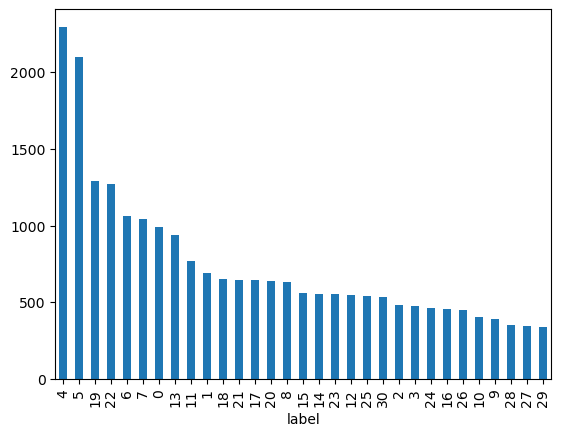

In [32]:
df_train.label.value_counts().plot(kind='bar')

In [35]:
speakerids = df_train['speakerId'].value_counts()

len(speakerids)

77

<Axes: xlabel='speakerId'>

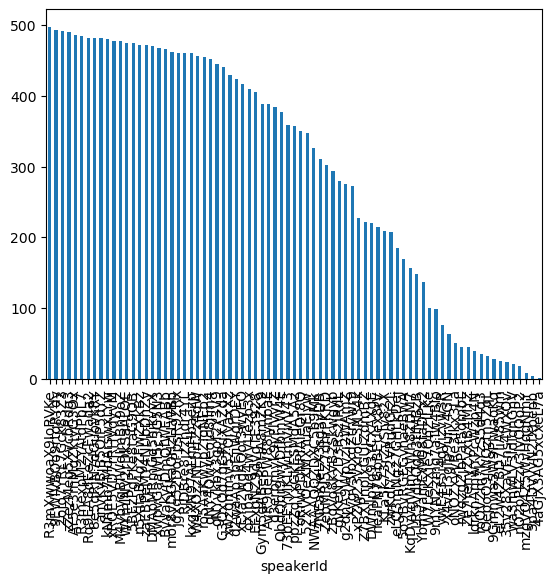

In [37]:
speakerids.plot(kind='bar')

In [41]:
pip install transformers

546.99s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached transformers-4.56.1-py3-none-any.whl.metadata (42 kB)
  Using cached huggingface_hub-0.34.4-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.0-cp39-abi3-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached safetensors-0.6.2-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached hf_xet-1.1.9-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.7 kB)
Using cached transformers-4.56.1-py3-none-any.whl (11.6 MB)
Using cached huggingface_hub-0.34.4-py3-none-any.whl (561 kB)
Using cached safetensors-0.6.2-cp38-abi3-macosx_11_0_arm64.whl (432 kB)
Using cached tokenizers-0.22.0-cp39-abi3-macosx_11_0_arm64.whl (2.9 MB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Using cached hf_xet-1.1.9-cp37-abi3-macosx_11_0_arm64.whl (2.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [43]:
from utils import set_seed

def get_forget_retain_split(df_train, min_samples_forget=100, ratio=0.025, seed=42, speaker_col='speakerId'):

    speakerids = df_train[speaker_col].value_counts()

    set_seed(seed)

    # sample speakers that have at least 200 samples until 2.5% of the total dataset samples are reached
    speakers = speakerids[speakerids>min_samples_forget].index.tolist()
    total_samples = 0 
    speakers_to_sample = []
    while total_samples < len(df_train)*ratio:
        speaker = random.choice(speakers)
        speakers_to_sample.append(speaker)
        total_samples += speakerids[speaker]

    df_forget = df_train[df_train['speakerId'].isin(speakers_to_sample)]
    df_retain = df_train[~df_train['speakerId'].isin(speakers_to_sample)]
    return df_forget, df_retain

df_forget, df_retain = get_forget_retain_split(df_train)

assert len(df_forget) + len(df_retain) == len(df_train)
assert len(set(df_forget['speakerId']).intersection(set(df_retain['speakerId']))) == 0

/opt/anaconda3/envs/aiproject_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [44]:
len(df_forget) / len(df_train)

0.035794570292235865

<Axes: xlabel='label'>

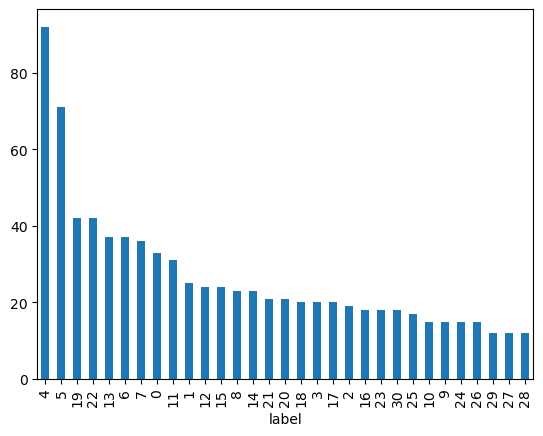

In [45]:
df_forget.label.value_counts().plot(kind='bar')

<Axes: xlabel='label'>

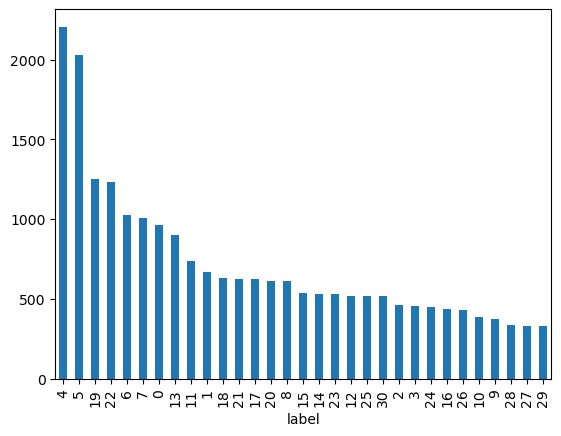

In [46]:
df_retain.label.value_counts().plot(kind='bar')

In [47]:
df_forget.to_csv('data_fsc/forget.csv', index=False)
df_retain.to_csv('data_fsc/retain.csv', index=False)